In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [6]:

%matplotlib inline

In [7]:
sns.set_style("whitegrid")

In [12]:
HouseDF = pd.read_csv(r"C:\Users\Utkarsha\Downloads\USA_Housing.csv")


In [13]:
print("Dataset loaded successfully!")
print("Shape of dataset:", HouseDF.shape)


Dataset loaded successfully!
Shape of dataset: (5000, 7)


In [14]:
print("\nFirst 5 rows:")
print(HouseDF.head())



First 5 rows:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA..

In [15]:
# 3. BASIC DATA INFORMATION
# ============================================================

print("\nDataset Information:")
HouseDF.info()

print("\nStatistical Summary:")
print(HouseDF.describe())

print("\nColumn Names:")
print(HouseDF.columns)

print("\nMissing Values:")
print(HouseDF.isnull().sum())




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB

Statistical Summary:
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.99

In [16]:
# 4. DATA CHECKING FUNCTION
# ============================================================

def check_data(data):
    """
    Displays basic information about the dataset.
    """
    
    print("========== DATA CHECK ==========")
    
    print("\nNumber of rows:", data.shape[0])
    print("Number of columns:", data.shape[1])
    
    print("\nMissing values:")
    print(data.isnull().sum())
    
    print("\nDuplicate rows:", data.duplicated().sum())
    
    print("\nData types:")
    print(data.dtypes)
    
    print("\n================================")


check_data(HouseDF)


========== DATA CHECK ==========

Number of rows: 5000
Number of columns: 7

Missing values:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Duplicate rows: 0

Data types:
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                          object
dtype: object



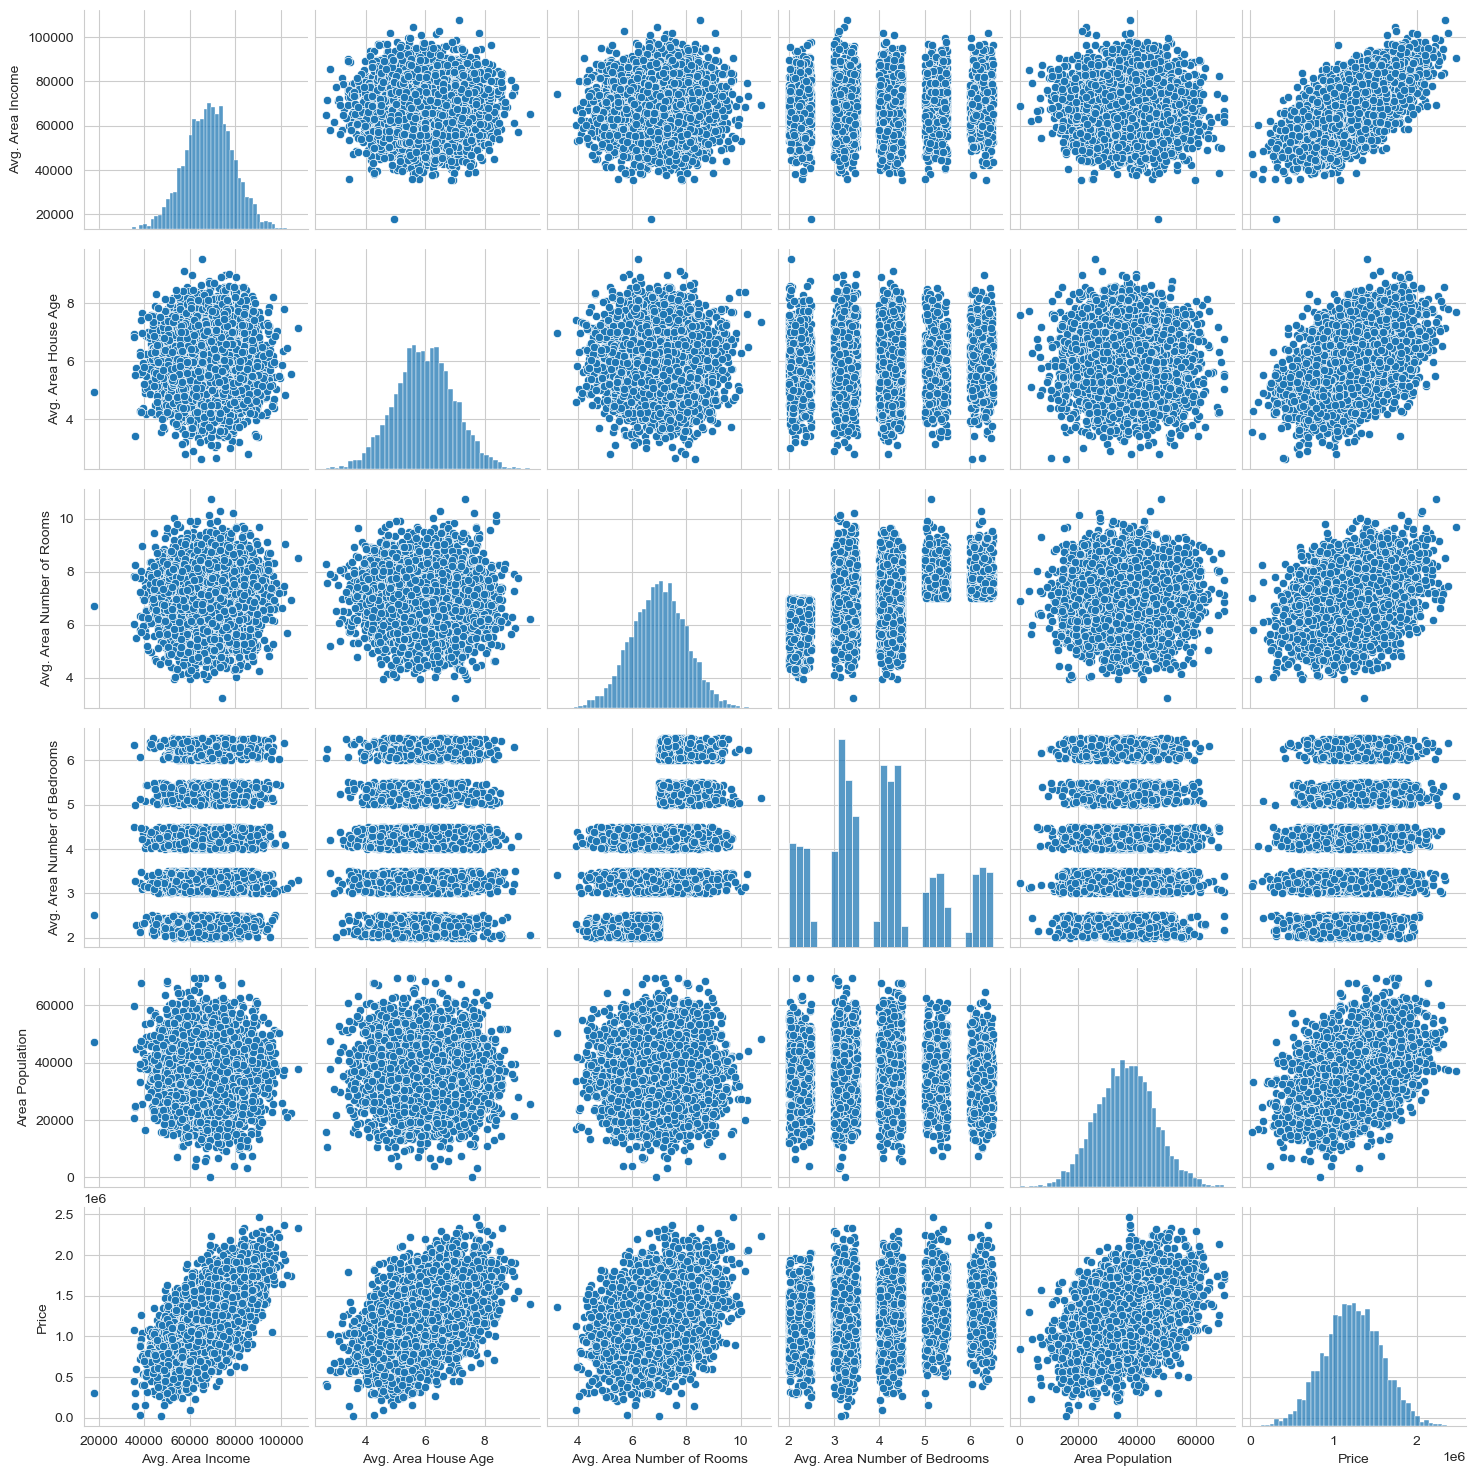

In [17]:
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

# Pairplot

sns.pairplot(HouseDF)
plt.show()


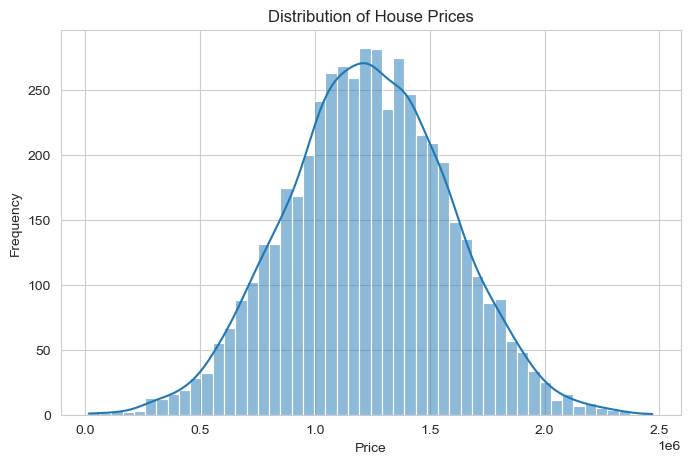

In [18]:
# 6. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    HouseDF["Price"],
    bins=50,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



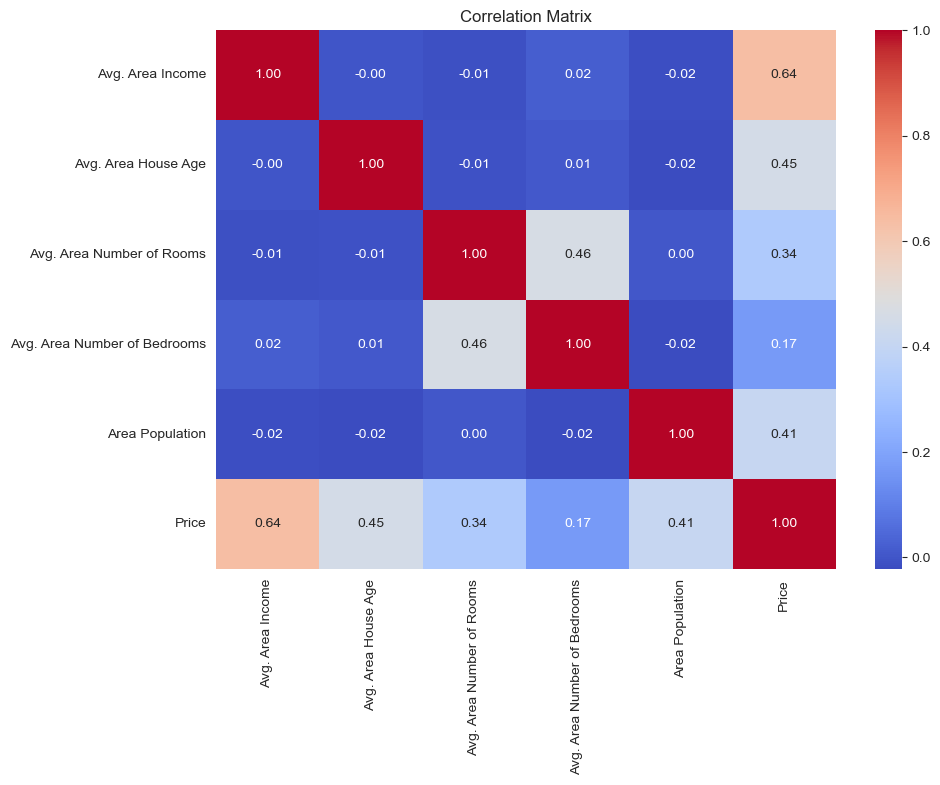

In [19]:
# 7. CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(10, 7))

correlation_matrix = HouseDF.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
# 8. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population"
]

X = HouseDF[features]

y = HouseDF["Price"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())



Features:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population  
0                          4.09     23086.800503  
1                          3.09     40173.072174  
2                          5.13     36882.159400  
3                          3.26     34310.242831  
4                          4.23     26354.109472  

Target:
0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64


In [21]:
# 9. SPLIT DATA INTO TRAIN AND TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=101
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)


Training data size: (3000, 5)
Testing data size: (2000, 5)


In [22]:
# 10. MODEL TRAINING FUNCTION
# ============================================================

def train_linear_regression(X_train, y_train):
    """
    Creates and trains a Linear Regression model.
    """
    
    model = LinearRegression()
    
    model.fit(X_train, y_train)
    
    return model


In [23]:
# Train model

lm = train_linear_regression(X_train, y_train)

print("\nLinear Regression model trained successfully!")



Linear Regression model trained successfully!


In [24]:
# 11. MODEL INTERCEPT
# ============================================================

print("\nModel Intercept:")
print(lm.intercept_)


Model Intercept:
-2640159.79685191


In [25]:
# 12. MODEL COEFFICIENTS
# ============================================================

coeff_df = pd.DataFrame(
    lm.coef_,
    X.columns,
    columns=["Coefficient"]
)

print("\nFeature Coefficients:")
print(coeff_df)



Feature Coefficients:
                                Coefficient
Avg. Area Income                  21.528276
Avg. Area House Age           164883.282027
Avg. Area Number of Rooms     122368.678027
Avg. Area Number of Bedrooms    2233.801864
Area Population                   15.150420


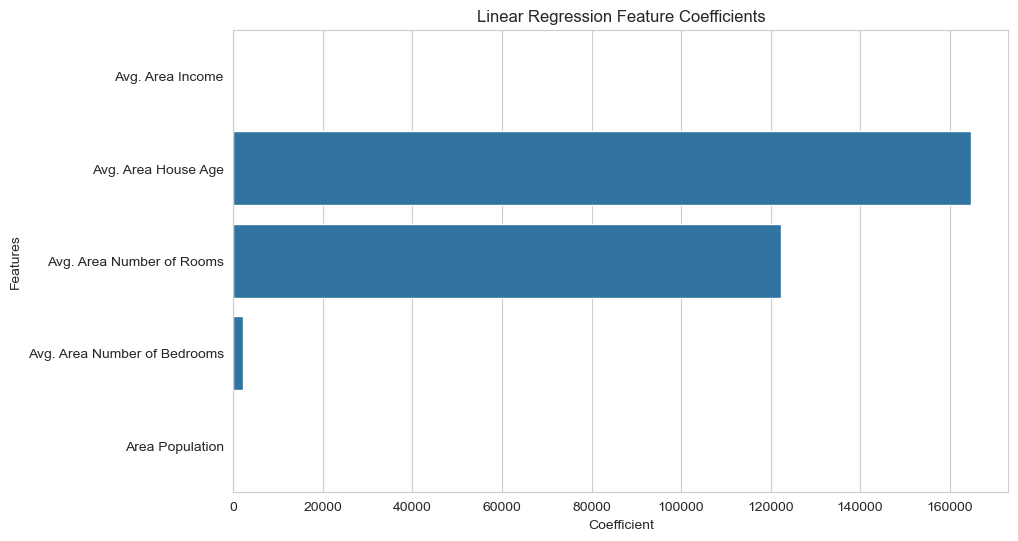

In [26]:
# 13. COEFFICIENT VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=coeff_df["Coefficient"],
    y=coeff_df.index
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()


In [27]:
# 14. MAKE PREDICTIONS
# ============================================================

predictions = lm.predict(X_test)

print("\nFirst 10 Predictions:")
print(predictions[:10])


First 10 Predictions:
[1260960.70567626  827588.75560352 1742421.24254328  974625.38739909
  998717.84202015  645754.08836701 1083215.90915516  855334.94872344
 1445671.40030584 1202846.01438938]


In [28]:
# 15. ACTUAL VS PREDICTED VALUES
# ============================================================

comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

print("\nActual vs Predicted:")
print(comparison_df.head(10))


Actual vs Predicted:
   Actual Price  Predicted Price
0  1.251689e+06     1.260961e+06
1  8.730483e+05     8.275888e+05
2  1.696978e+06     1.742421e+06
3  1.063964e+06     9.746254e+05
4  9.487883e+05     9.987178e+05
5  7.300436e+05     6.457541e+05
6  1.166925e+06     1.083216e+06
7  7.054441e+05     8.553349e+05
8  1.499989e+06     1.445671e+06
9  1.288199e+06     1.202846e+06


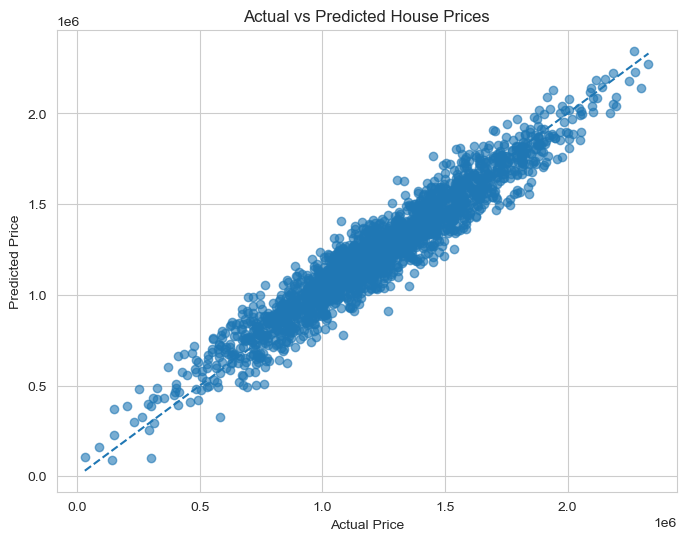

In [29]:
# 16. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

# Perfect prediction line

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [30]:
# 17. RESIDUAL CALCULATION
# ============================================================

residuals = y_test - predictions

print("\nFirst 10 Residuals:")
print(residuals.head(10))



First 10 Residuals:
1718     -9272.089973
2511     45459.564039
345     -45443.579711
2521     89338.900475
54      -49929.566311
2866     84289.556693
2371     83709.236994
2952   -149890.831933
45       54317.479217
4653     85353.138340
Name: Price, dtype: float64


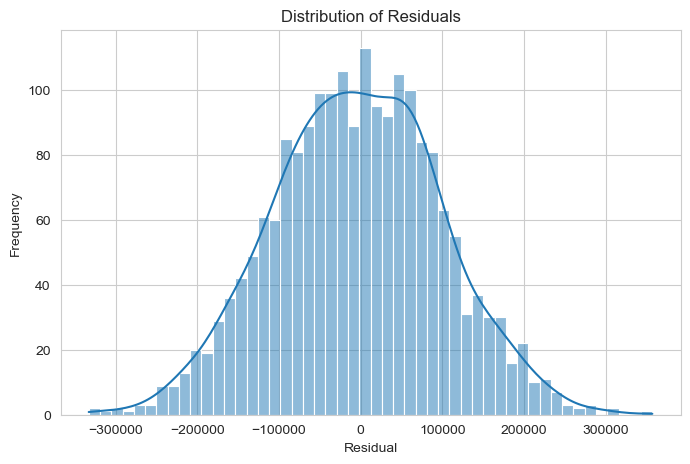

In [31]:
# 18. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()


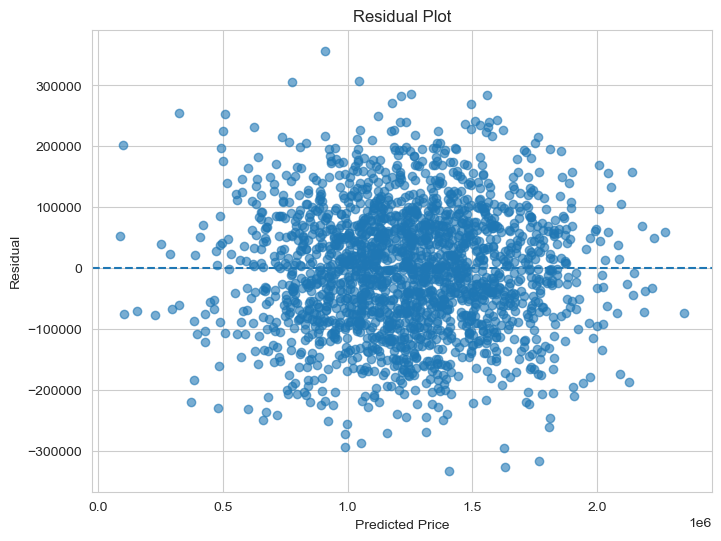

In [32]:
# 19. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [33]:
# 20. REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_test, y_test):
    """
    Calculates different regression evaluation metrics.
    """
    
    predictions = model.predict(X_test)
    
    mae = metrics.mean_absolute_error(
        y_test,
        predictions
    )
    
    mse = metrics.mean_squared_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(mse)
    
    r2 = metrics.r2_score(
        y_test,
        predictions
    )
    
    # Mean Absolute Percentage Error
    mape = np.mean(
        np.abs((y_test - predictions) / y_test)
    ) * 100
    
    return mae, mse, rmse, r2, mape



In [34]:
# 21. MODEL EVALUATION
# ============================================================

mae, mse, rmse, r2, mape = evaluate_model(
    lm,
    X_test,
    y_test
)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
print("MAPE :", mape, "%")

print("=======================================")


========== MODEL PERFORMANCE ==========
MAE  : 82288.22251914954
MSE  : 10460958907.209503
RMSE : 102278.82922291153
R²   : 0.91768240096492
MAPE : 7.813351207986839 %


In [35]:
# 22. ADJUSTED R-SQUARED
# ============================================================

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("\nAdjusted R²:", adjusted_r2)


Adjusted R²: 0.9174759877276204


In [36]:
# 23. CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    lm,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n========== CROSS VALIDATION ==========")

print("R² scores:")
print(cv_scores)

print("\nMean Cross-Validation R²:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

print("=======================================")


========== CROSS VALIDATION ==========
R² scores:
[0.91758995 0.92030155 0.91524299 0.92085038 0.91381118]

Mean Cross-Validation R²:
0.9175592097606875

Standard Deviation:
0.0027483021477870254


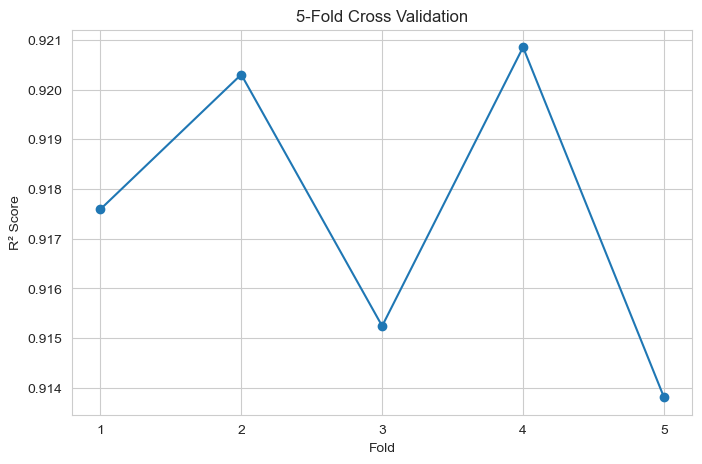

In [37]:
# 24. CROSS-VALIDATION VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o"
)

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-Fold Cross Validation")

plt.xticks(range(1, 6))

plt.show()


In [38]:
# 25. FUNCTION TO PREDICT HOUSE PRICE
# ============================================================

def predict_house_price(
    model,
    income,
    house_age,
    rooms,
    bedrooms,
    population
):
    """
    Predicts house price for a new house.
    """
    
    new_house = pd.DataFrame({
        "Avg. Area Income": [income],
        "Avg. Area House Age": [house_age],
        "Avg. Area Number of Rooms": [rooms],
        "Avg. Area Number of Bedrooms": [bedrooms],
        "Area Population": [population]
    })
    
    predicted_price = model.predict(new_house)
    
    return predicted_price[0]


In [39]:
# 26. EXAMPLE NEW HOUSE PREDICTION
# ============================================================

new_price = predict_house_price(
    lm,
    income=70000,
    house_age=6,
    rooms=7,
    bedrooms=4,
    population=35000
)

print("\n========== NEW HOUSE PREDICTION ==========")

print(
    "Predicted House Price: ${:,.2f}".format(new_price)
)

print("===========================================")



========== NEW HOUSE PREDICTION ==========
Predicted House Price: $1,251,899.84


In [40]:
# 27. FUNCTION TO DISPLAY MODEL SUMMARY
# ============================================================

def model_summary(model, X, X_test, y_test):
    """
    Displays complete model information.
    """
    
    predictions = model.predict(X_test)
    
    r2 = metrics.r2_score(
        y_test,
        predictions
    )
    
    mae = metrics.mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        metrics.mean_squared_error(
            y_test,
            predictions
        )
    )
    
    print("\n========== MODEL SUMMARY ==========")
    
    print("Model: Linear Regression")
    
    print("\nNumber of features:", X.shape[1])
    
    print("Training samples:", X_train.shape[0])
    
    print("Testing samples:", X_test.shape[0])
    
    print("\nIntercept:")
    print(model.intercept_)
    
    print("\nR² Score:", r2)
    
    print("MAE:", mae)
    
    print("RMSE:", rmse)
    
    print("\n===================================")


In [41]:
# 28. DISPLAY FINAL MODEL SUMMARY
# ============================================================

model_summary(
    lm,
    X,
    X_test,
    y_test
)


========== MODEL SUMMARY ==========
Model: Linear Regression

Number of features: 5
Training samples: 3000
Testing samples: 2000

Intercept:
-2640159.79685191

R² Score: 0.91768240096492
MAE: 82288.22251914954
RMSE: 102278.82922291153



In [42]:
# 29. FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "Adjusted R²",
        "MAPE",
        "CV Mean R²"
    ],
    
    "Value": [
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]
})

print("\n========== FINAL RESULTS ==========")
print(results)




========== FINAL RESULTS ==========
        Metric         Value
0          MAE  8.228822e+04
1          MSE  1.046096e+10
2         RMSE  1.022788e+05
3     R² Score  9.176824e-01
4  Adjusted R²  9.174760e-01
5         MAPE  7.813351e+00
6   CV Mean R²  9.175592e-01


In [43]:
# 30. SAVE PREDICTIONS TO CSV
# ============================================================

comparison_df.to_csv(
    "house_price_predictions.csv",
    index=False
)

print("\nPredictions saved as: house_price_predictions.csv")




Predictions saved as: house_price_predictions.csv
